In [42]:

from google.colab import drive
drive.mount('/content/drive')

!pip install scipy zstandard torch matplotlib numpy


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [43]:

import os
import math
import struct
import numpy as np
import scipy.signal
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

CHECKPOINT_PATH = "/content/avdct_net_checkpoint.pth"
BONN_DATA_DIR   = "/content/drive/MyDrive/BonnDataset"

NUM_CHANNELS  = 64
FS            = 160
L             = 64
N_SUBBANDS    = 3
TAU           = 2
OMEGA         = 1.6
QUANT_SCALE   = (10 ** TAU) / OMEGA
SPARSITY_RHO  = 0.60
DEVICE        = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

FOLDERS = ['F', 'N', 'O', 'S', 'Z']

print(f'Using device: {DEVICE}')
print(f'Checkpoint:   {CHECKPOINT_PATH}')
print(f'Data dir:     {BONN_DATA_DIR}')


Using device: cpu
Checkpoint:   /content/avdct_net_checkpoint.pth
Data dir:     /content/drive/MyDrive/BonnDataset


In [44]:

import math
import torch
import torch.nn as nn
import torch.nn.functional as F

def get_dct_matrix(N):
    dct = torch.zeros(N, N)
    for k in range(N):
        for n in range(N):
            dct[n, k] = math.cos(math.pi * k * (2 * n + 1) / (2 * N))
        dct[:, k] *= math.sqrt(2.0 / N)
    dct[:, 0] *= 1.0 / math.sqrt(2.0)
    return dct

class HardThresholding(nn.Module):
    """
    Learnable hard-thresholding operator (Eq. 8-9 in the paper).
    """
    def __init__(self, size):
        super().__init__()
        self.t = nn.Parameter(torch.full((size,), 0.01))

    def forward(self, x_hat):
        soft = torch.sign(x_hat) * F.relu(torch.abs(x_hat) - torch.abs(self.t))
        return soft + torch.abs(self.t) * torch.sign(soft)

class EdgeGateway(nn.Module):
    def __init__(self, num_channels=NUM_CHANNELS, block_len=L, n_subbands=N_SUBBANDS):
        super().__init__()
        self.block_len = block_len
        self.n_subbands = n_subbands
        self.shared_linear = nn.Linear(block_len, block_len)
        self.register_buffer('dct_mat', get_dct_matrix(block_len))
        self.thresholds = nn.ModuleList([
            HardThresholding(block_len) for _ in range(n_subbands)
        ])
        self.scaling_vectors = nn.ParameterList([
            nn.Parameter(torch.ones(block_len)) for _ in range(n_subbands)
        ])
        self.conv1x1 = nn.Conv1d(
            in_channels=n_subbands, out_channels=1, kernel_size=1, bias=False
        )

    def forward(self, x):
        B, C, block_len = x.shape
        x_flat = x.reshape(-1, block_len)
        x_tilde = self.shared_linear(x_flat)
        x_hat = torch.matmul(x_tilde, self.dct_mat)
        subbands = []
        for n in range(self.n_subbands):
            h_n = self.thresholds[n](x_hat)
            s_n = h_n * self.scaling_vectors[n]
            subbands.append(s_n)
        stacked = torch.stack(subbands, dim=1)
        latent = self.conv1x1(stacked).squeeze(1)
        return latent.reshape(B, C, block_len)

class FogGateway(nn.Module):
    def __init__(self, num_channels=NUM_CHANNELS, block_len=L, num_heads=4):
        super().__init__()
        self.C = num_channels
        self.block_len = block_len
        self.f = nn.Parameter(torch.zeros(num_channels, block_len))
        self.g = nn.Parameter(torch.zeros(num_channels, block_len))
        self.mha = nn.MultiheadAttention(
            embed_dim=block_len, num_heads=num_heads, batch_first=True
        )
        self.hard_threshold = HardThresholding(block_len)
        self.register_buffer('idct_mat', get_dct_matrix(block_len).t())
        self.final_linear = nn.Linear(block_len, block_len)

    def forward(self, y):
        B, C, block_len = y.shape
        u = torch.zeros_like(y)
        u[:, 0, :] = y[:, 0, :]
        for c in range(1, C):
            u[:, c, :] = y[:, c, :] + self.f[c-1] * y[:, c-1, :]
        s = torch.zeros_like(u)
        s[:, -1, :] = u[:, -1, :]
        for c in range(C - 2, -1, -1):
            s[:, c, :] = u[:, c, :] + self.g[c] * u[:, c+1, :]
        attn_out, _ = self.mha(s, s, s)
        s_tilde = attn_out + s
        s_hat = self.hard_threshold(s_tilde)
        reconstructed = torch.matmul(s_hat, self.idct_mat)
        output = self.final_linear(reconstructed)
        return output.reshape(B, C, block_len)
print('Model definitions updated.')


Model definitions updated.


In [45]:
import math
import torch
import torch.nn.functional as F


class DataConversionBlock:
    def __init__(self, scale_factor=QUANT_SCALE):
        self.scale_factor = scale_factor
    def quantize(self, latent_tensor):
        arr = latent_tensor.detach().cpu().numpy()
        quantized = np.round(arr * self.scale_factor).astype(np.int32)
        return quantized, arr.shape
    def dequantize(self, quantized, device='cpu'):
        arr = quantized.astype(np.float32) / self.scale_factor
        return torch.from_numpy(arr).to(device)
    def compute_quantization_error(self, original_tensor, quantized):
        original = original_tensor.detach().cpu().numpy()
        reconstructed = quantized.astype(np.float64) / self.scale_factor
        return np.mean(np.abs(original - reconstructed))
    @staticmethod
    def sparsity(quantized_array):
        return float((quantized_array == 0).sum()) / quantized_array.size


class HybridCodingBlock:
    def compress(self, quantized_array):
        flat = quantized_array.transpose(2, 0, 1).flatten()
        n = len(flat)
        original_size = n * 2
        max_val = np.max(np.abs(flat))
        if max_val < 128:
            dtype_id = 1; raw_bytes = flat.astype(np.int8).tobytes()
        elif max_val < 32768:
            dtype_id = 2; raw_bytes = flat.astype(np.int16).tobytes()
        else:
            dtype_id = 4; raw_bytes = flat.astype(np.int32).tobytes()
        header = struct.pack('<BI', dtype_id, n)
        payload = header + raw_bytes
        import zstandard as zstd
        cctx = zstd.ZstdCompressor(level=22)
        compressed_data = cctx.compress(payload)
        c_size = len(compressed_data)
        zero_frac = float((flat == 0).sum()) / max(n, 1)
        stats = {
            'original_size': original_size, 'packing_size': len(raw_bytes),
            'zstd_size': c_size, 'zero_fraction': zero_frac,
            'compression_power': (1 - (c_size / original_size)) * 100
        }
        return compressed_data, stats

    def decompress(self, compressed_data, original_shape):
        import zstandard as zstd
        dctx = zstd.ZstdDecompressor()
        payload = dctx.decompress(compressed_data)
        dtype_id, n_elements = struct.unpack('<BI', payload[:5])
        raw_bytes = payload[5:]
        dtype_map = {1: np.int8, 2: np.int16, 4: np.int32}
        flat = np.frombuffer(raw_bytes, dtype=dtype_map[dtype_id]).astype(np.int32)
        B, C, L_dim = original_shape
        return flat.reshape((L_dim, B, C)).transpose(1, 2, 0)


class EdgeToFogPipeline:
    def __init__(self, scale_factor=QUANT_SCALE):
        self.data_converter = DataConversionBlock(scale_factor=scale_factor)
        self.hybrid_coder = HybridCodingBlock()
    def process(self, latent_tensor, device='cpu'):
        quantized, shape = self.data_converter.quantize(latent_tensor)
        compressed_data, stats = self.hybrid_coder.compress(quantized)
        decompressed_quantized = self.hybrid_coder.decompress(compressed_data, shape)
        decompressed_tensor = self.data_converter.dequantize(decompressed_quantized, device=device)
        stats['quantization_mae'] = self.data_converter.compute_quantization_error(latent_tensor, quantized)
        return decompressed_tensor, stats


# ── Metrics ──
def compute_prd(original, reconstructed):
    num = torch.norm(original - reconstructed).item()
    den = torch.norm(original).item() + 1e-12
    return 100.0 * num / den

def compute_prdn(original, reconstructed):
    num = torch.sum((original - reconstructed) ** 2)
    mean_val = torch.mean(original)
    den = torch.sum((original - mean_val) ** 2) + 1e-12
    return 100.0 * torch.sqrt(num / den).item()

def compute_qs(cr, prd):
    return cr / (prd + 1e-12)

def compute_rmse(original, reconstructed):
    return torch.sqrt(F.mse_loss(original, reconstructed)).item()

def compute_snr(original, reconstructed):
    signal_power = torch.sum(original ** 2).item()
    noise_power = torch.sum((original - reconstructed) ** 2).item() + 1e-12
    return 10.0 * math.log10(signal_power / noise_power)

def compute_psnr(original, reconstructed):
    peak = torch.max(torch.abs(original)).item()
    mse = F.mse_loss(original, reconstructed).item() + 1e-12
    return 20.0 * math.log10(peak + 1e-12) - 10.0 * math.log10(mse)

def compute_mse(original, reconstructed):
    return F.mse_loss(original, reconstructed).item()

def compute_bps(compressed_size_bytes, n_total_samples, n_channels):
    total_samples = n_total_samples * n_channels
    return (compressed_size_bytes * 8) / max(total_samples, 1)

def compute_correlation(original, reconstructed):
    orig = original.flatten().detach().cpu().numpy()
    recon = reconstructed.flatten().detach().cpu().numpy()
    return np.corrcoef(orig, recon)[0, 1]

def compute_msc(original, reconstructed, fs=FS):
    orig = original.flatten().detach().cpu().numpy()
    recon = reconstructed.flatten().detach().cpu().numpy()
    f, Cxy = scipy.signal.coherence(orig, recon, fs=fs)
    return np.mean(Cxy)

def compute_compression_ratio(originals_tensor, compressed_size_bytes):
    q_r = originals_tensor.numel() * 2
    q_c = max(compressed_size_bytes, 1)
    return q_r / q_c

import matplotlib.pyplot as plt
import numpy as np

def plot_bonn_reconstruction(original, reconstructed, folder_name, sample_idx=0):
    """
    Vertical 3x1 Layout:
    - Dark high-contrast colors (Navy, Maroon, Forest Green)
    - Left-aligned legends
    - Increased font sizes
    - No global title
    """
    # 1. Data Preparation
    orig = original.detach().cpu().numpy().flatten()
    recon = reconstructed.detach().cpu().numpy().flatten()
    error = orig - recon
    time_pts = np.arange(len(orig))

    # 2. Scaling & Font Configuration
    y_min = min(orig.min(), recon.min(), error.min())
    y_max = max(orig.max(), recon.max(), error.max())
    padding = (y_max - y_min) * 0.1
    ylim = (y_min - padding, y_max + padding)

    FS_HEADING = 22  # Subplot titles
    FS_LABEL   = 18  # X/Y Axis labels
    FS_TICKS   = 14  # Axis ticks
    FS_LEGEND  = 16  # Legend font

    # 3. Create Figure (3 rows, 1 column)
    fig, axes = plt.subplots(3, 1, figsize=(14, 18), sharex=True)

    # --- Plot 1: Original EEG (Navy Blue) ---
    axes[0].plot(time_pts, orig, color='#000080', linewidth=2.0, label='Original EEG')
    axes[0].set_title(f"Original Signal: {folder_name}", fontsize=FS_HEADING, fontweight='bold', pad=15)
    axes[0].set_ylabel("Amplitude (uV)", fontsize=FS_LABEL, fontweight='bold')
    axes[0].tick_params(axis='both', labelsize=FS_TICKS)
    axes[0].legend(loc='upper left', fontsize=FS_LEGEND, frameon=True)
    axes[0].grid(True, linestyle='--', alpha=0.3)
    axes[0].set_ylim(ylim)

    # --- Plot 2: Reconstructed EEG (Dark Maroon) ---
    axes[1].plot(time_pts, recon, color='#800000', linewidth=2.0, label='Hybrid Reconstruction')
    axes[1].set_title("Reconstructed Signal", fontsize=FS_HEADING, fontweight='bold', pad=15)
    axes[1].set_ylabel("Amplitude (uV)", fontsize=FS_LABEL, fontweight='bold')
    axes[1].tick_params(axis='both', labelsize=FS_TICKS)
    axes[1].legend(loc='upper left', fontsize=FS_LEGEND, frameon=True)
    axes[1].grid(True, linestyle='--', alpha=0.3)
    axes[1].set_ylim(ylim)

    # --- Plot 3: Error / Residual (Dark Forest Green) ---
    axes[2].plot(time_pts, error, color='#006400', linewidth=1.5, label='Residual Error')
    axes[2].axhline(0, color='black', linewidth=1.0, linestyle='--')
    axes[2].set_title("Reconstruction Error", fontsize=FS_HEADING, fontweight='bold', pad=15)
    axes[2].set_xlabel("Sample Index", fontsize=FS_LABEL, fontweight='bold')
    axes[2].set_ylabel("Delta (uV)", fontsize=FS_LABEL, fontweight='bold')
    axes[2].tick_params(axis='both', labelsize=FS_TICKS)
    axes[2].legend(loc='upper left', fontsize=FS_LEGEND, frameon=True)
    axes[2].grid(True, linestyle='--', alpha=0.3)
    axes[2].set_ylim(ylim)

    # 4. Layout Cleanup
    plt.tight_layout()
    plt.savefig(f"reconstruction_3x1_{folder_name}.png", dpi=200, bbox_inches='tight')
    plt.show()

In [46]:

import scipy.signal

def bandpass_filter(data, fs=160, lowcut=0.5, highcut=40.0, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = scipy.signal.butter(order, [low, high], btype='band')
    return scipy.signal.filtfilt(b, a, data)

def zscore_normalize(data):
    mean = np.mean(data)
    std = np.std(data) + 1e-8
    return (data - mean) / std

def load_bonn_folder(folder_path, block_len=L, num_channels=NUM_CHANNELS):
    samples_needed = num_channels * block_len
    tensors = []
    # Fix: Case-insensitive extension check for .txt or .TXT
    files = sorted([f for f in os.listdir(folder_path) if f.lower().endswith('.txt')])
    for fname in files:
        fpath = os.path.join(folder_path, fname)
        try:
            raw = np.loadtxt(fpath, dtype=np.float64)
            if len(raw) < samples_needed: continue
            segment = raw[:samples_needed]
            filt = bandpass_filter(segment)
            norm = zscore_normalize(filt)
            tensor = torch.tensor(norm, dtype=torch.float32).reshape(1, num_channels, block_len)
            tensors.append(tensor)
        except Exception as e: print(f'  [ERR] {fname}: {e}')
    return tensors, files
print('Loader ready.')


Loader ready.



  Initial Dataset Visualization (One sample per class)


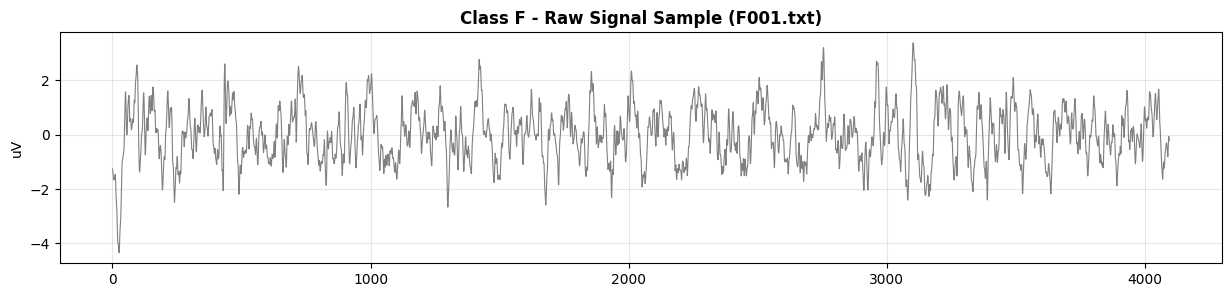

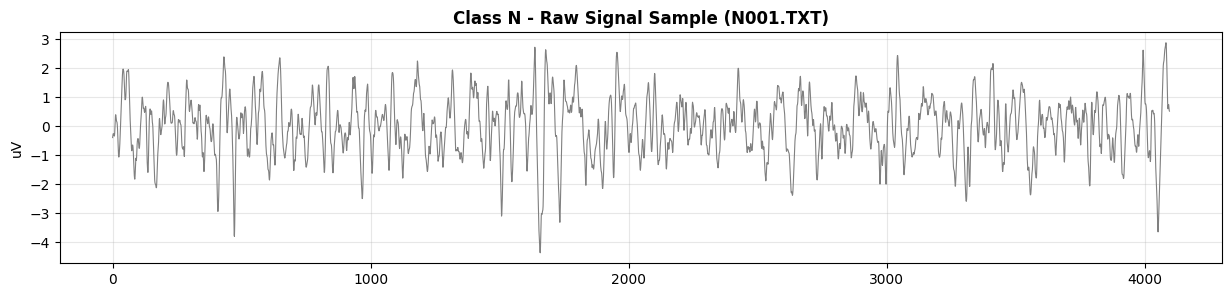

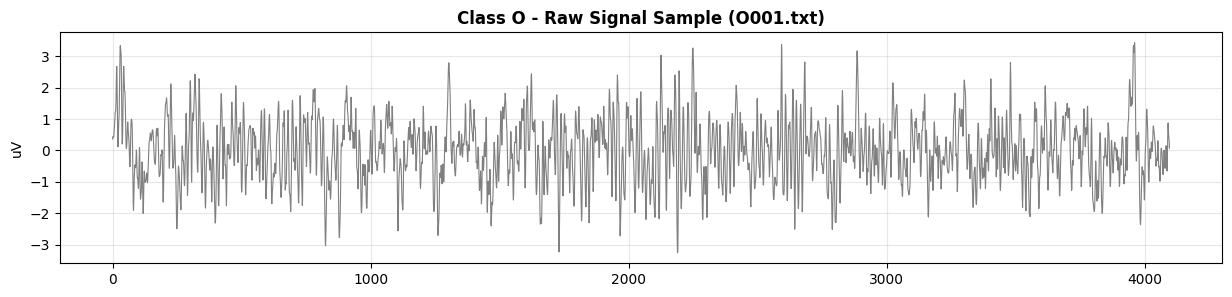

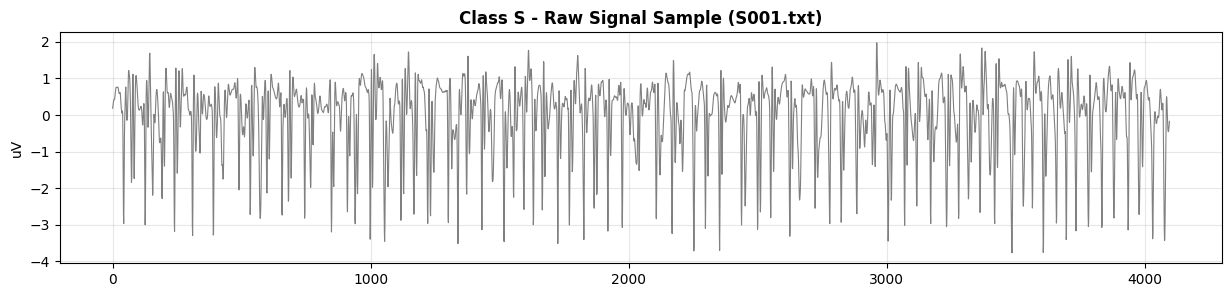

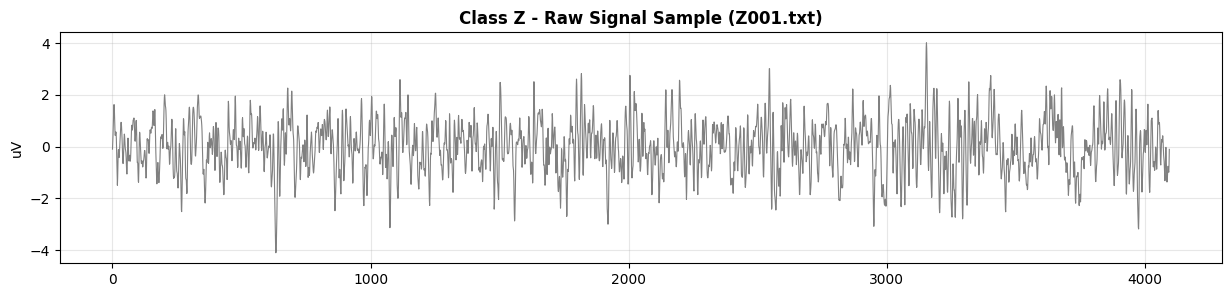

In [47]:
# Visualize one file from each folder immediately after loading
print("\n" + "="*50)
print("  Initial Dataset Visualization (One sample per class)")
print("="*50)

for folder_name in FOLDERS:
    folder_path = os.path.join(BONN_DATA_DIR, folder_name)
    if os.path.isdir(folder_path):
        samples, fnames = load_bonn_folder(folder_path)
        if samples:
            raw_sig = samples[0].detach().cpu().numpy().flatten()
            plt.figure(figsize=(15, 3))
            plt.plot(raw_sig, color='gray', linewidth=0.8)
            plt.title(f"Class {folder_name} - Raw Signal Sample ({fnames[0]})", fontweight='bold')
            plt.ylabel("uV")
            plt.grid(True, alpha=0.3)
            plt.show()

In [48]:

CHECKPOINT_PATH = "/content/drive/MyDrive/avdct_net_checkpoint.pth"

checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
edge = EdgeGateway(64, 64).to(DEVICE)
fog  = FogGateway(64, 64).to(DEVICE)

edge.load_state_dict(checkpoint['edge_state_dict'])
fog.load_state_dict(checkpoint['fog_state_dict'])

edge.eval()
fog.eval()
print(f'Model loaded: {CHECKPOINT_PATH}')

Model loaded: /content/drive/MyDrive/avdct_net_checkpoint.pth



  Processing folder: F
  Loaded 100 files
    25/100 done
    50/100 done
    75/100 done
    100/100 done

  ── F Results ──
  Baseline: PRD=4.8266% SNR=26.33dB Corr=0.999200
  Hybrid:   PRD=9.5745% SNR=20.38dB Corr=0.995878
  CR=8.53x  CP=88.28%  BPS=1.8753  QS=0.8911
  Sparsity=0.6792  QuantMAE=0.001809


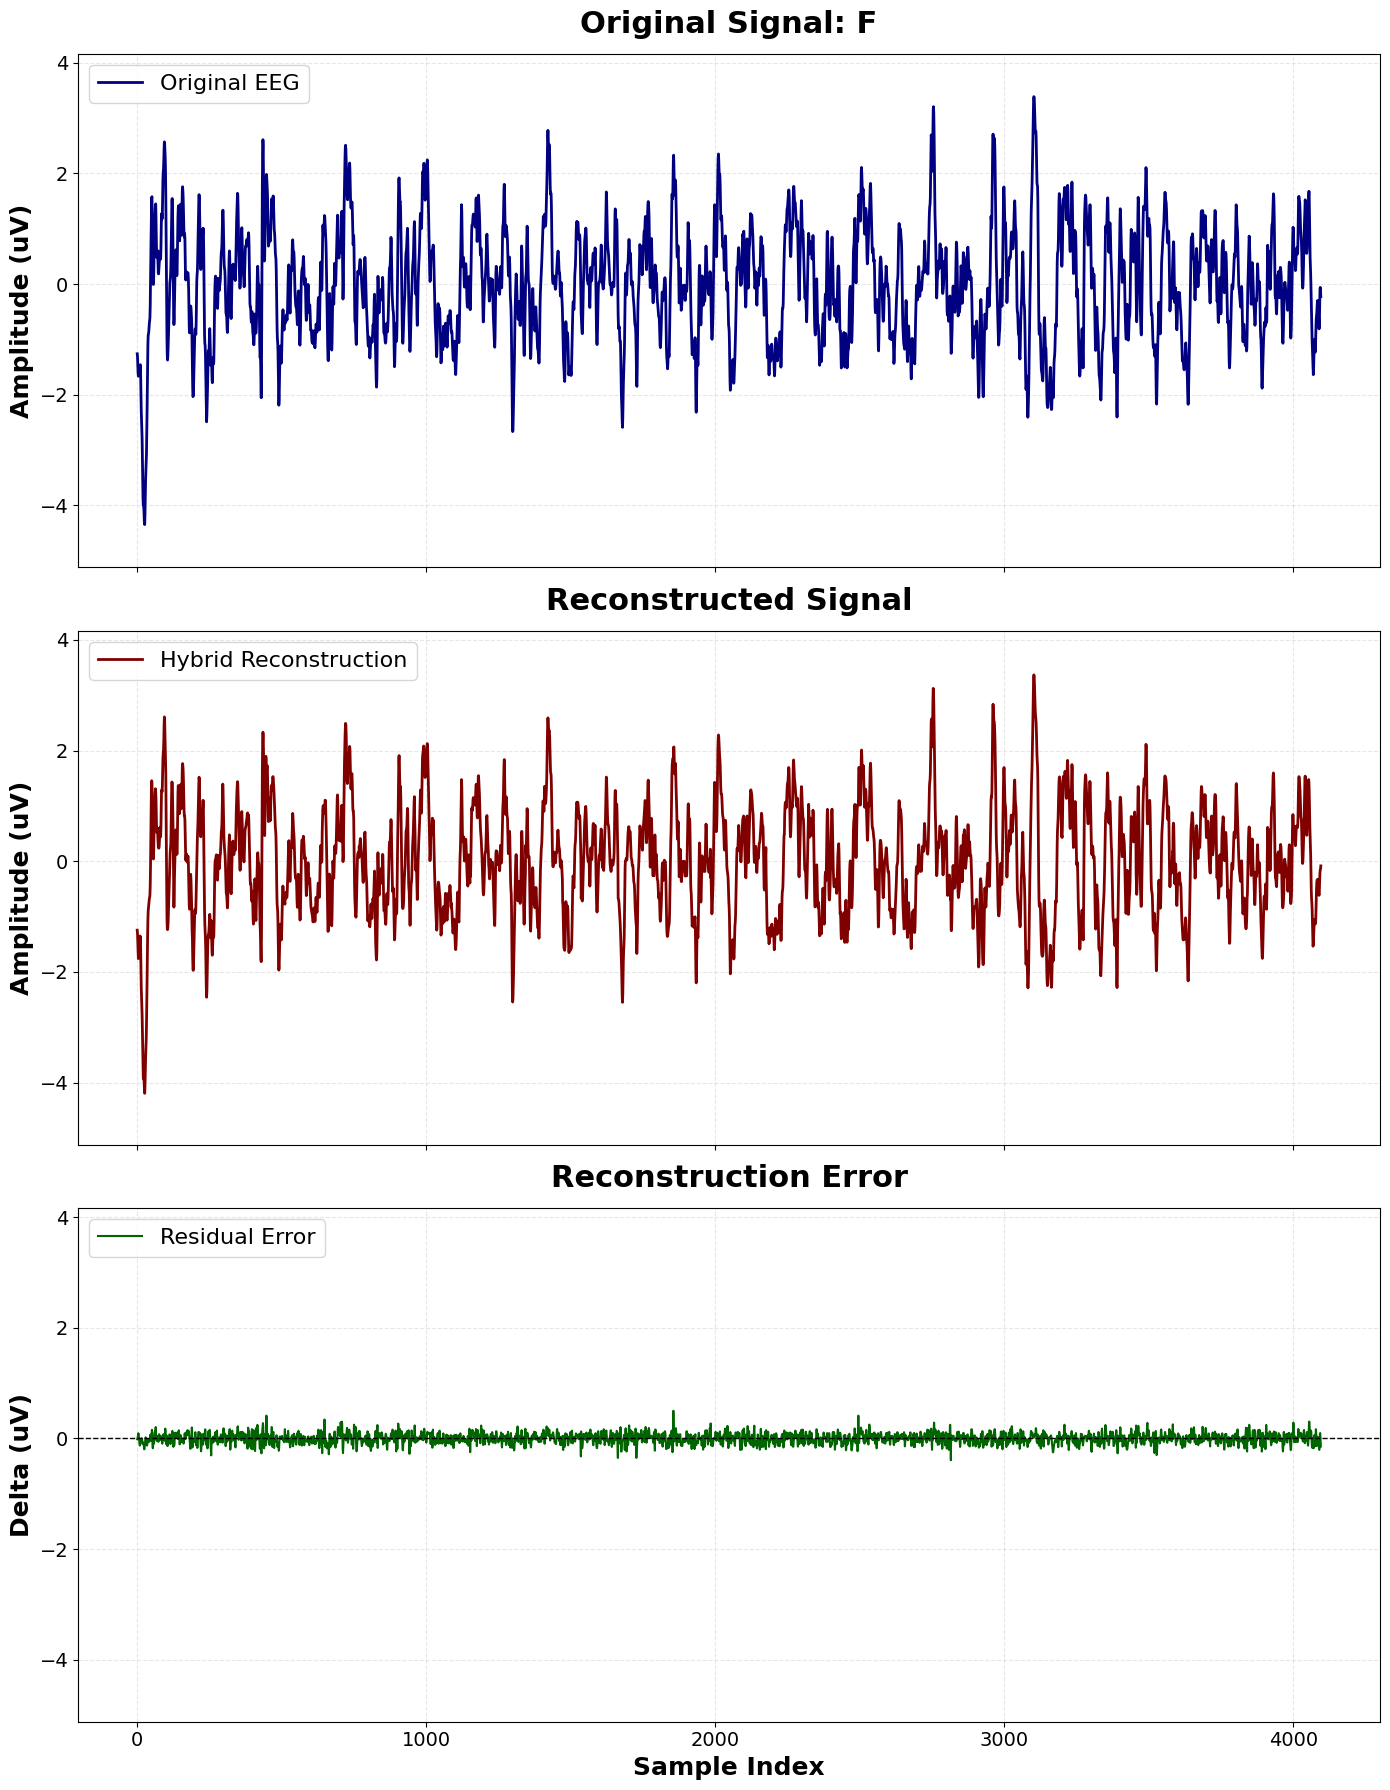


  Processing folder: N
  Loaded 100 files
    25/100 done
    50/100 done
    75/100 done
    100/100 done

  ── N Results ──
  Baseline: PRD=4.8363% SNR=26.31dB Corr=0.999193
  Hybrid:   PRD=9.4361% SNR=20.50dB Corr=0.995977
  CR=8.46x  CP=88.19%  BPS=1.8903  QS=0.8970
  Sparsity=0.6713  QuantMAE=0.001823


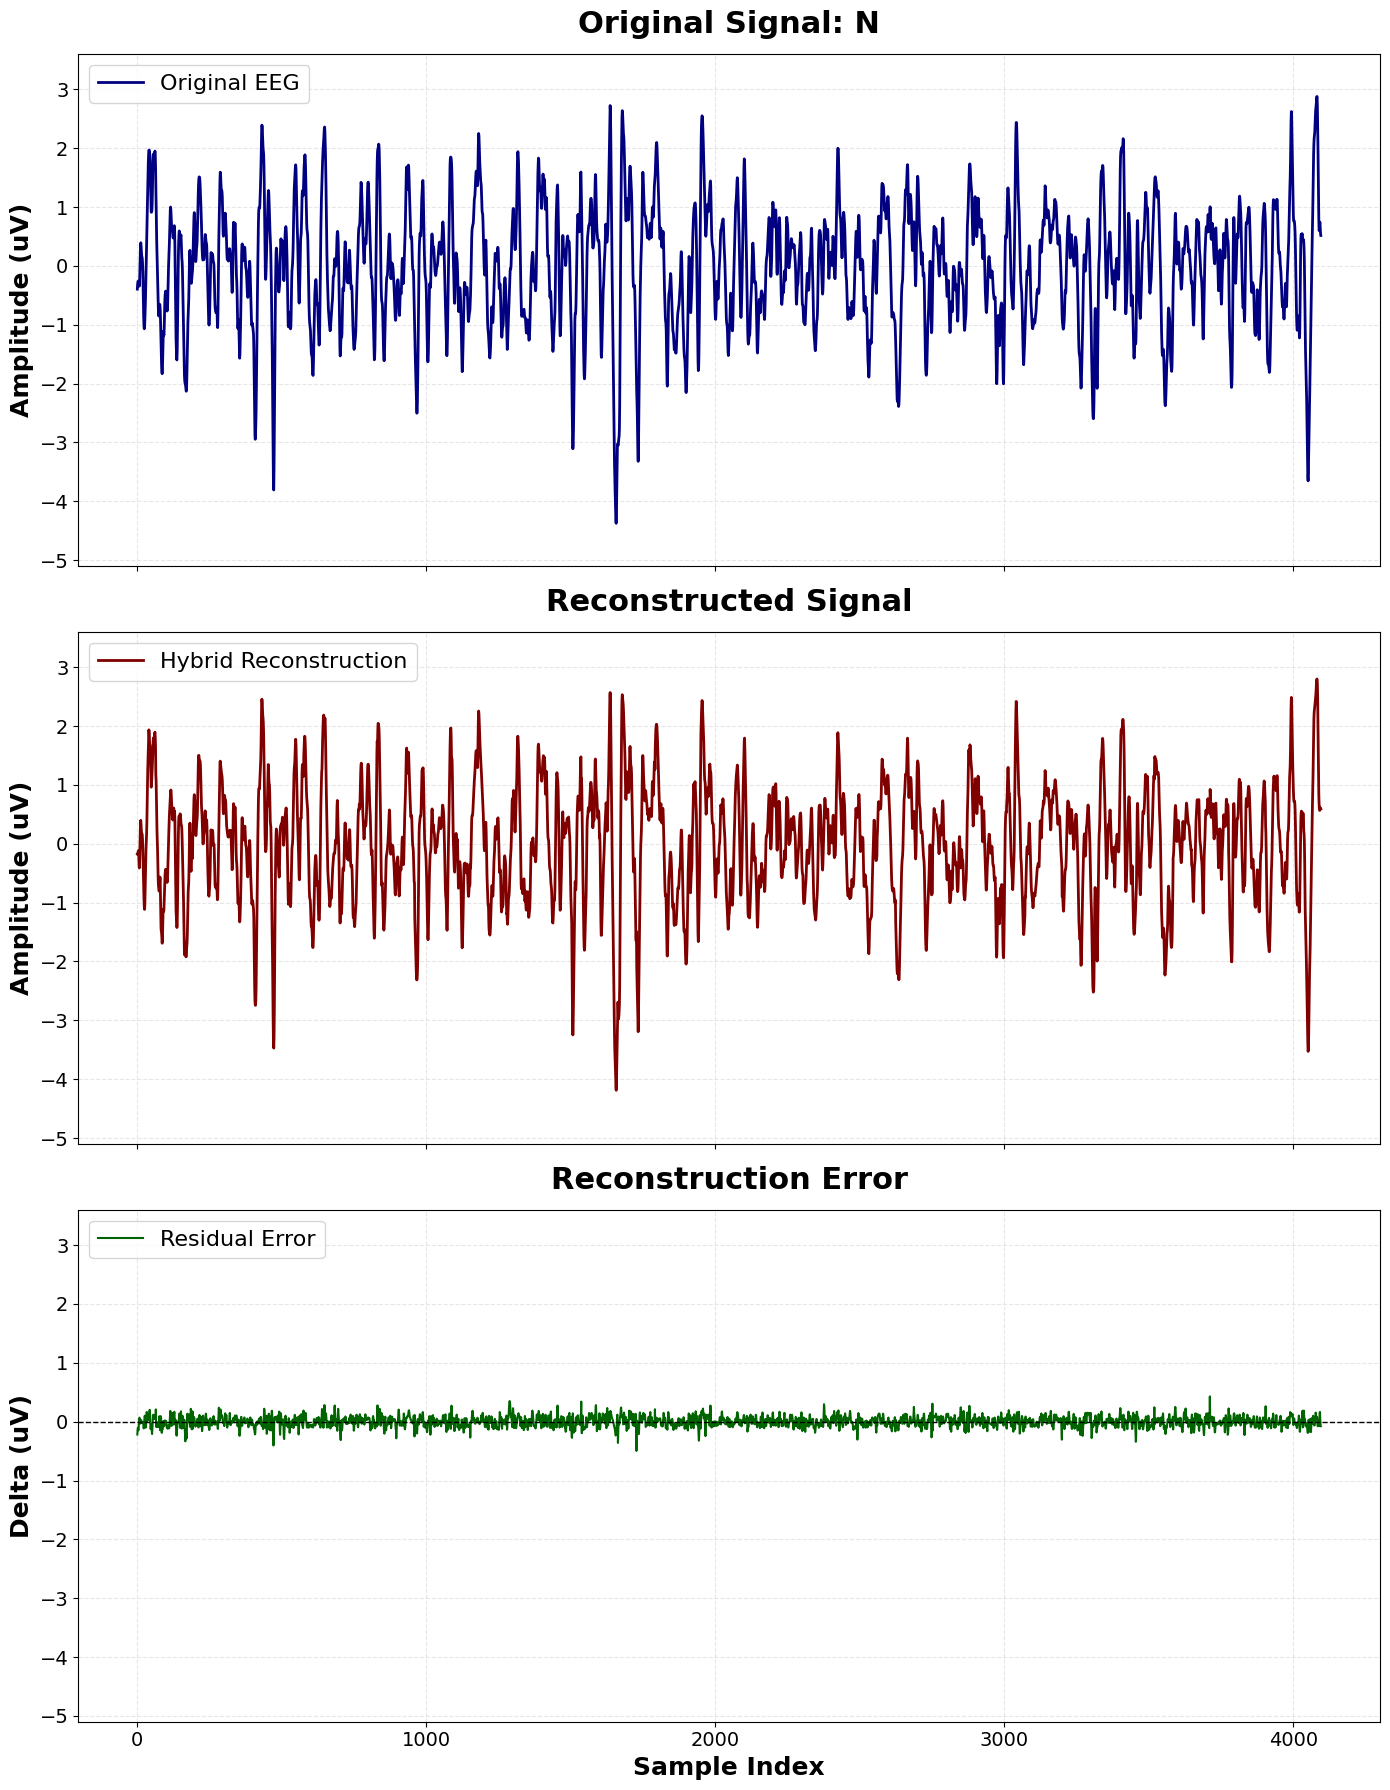


  Processing folder: O
  Loaded 100 files
    25/100 done
    50/100 done
    75/100 done
    100/100 done

  ── O Results ──
  Baseline: PRD=6.9528% SNR=23.16dB Corr=0.998100
  Hybrid:   PRD=14.4722% SNR=16.79dB Corr=0.990505
  CR=7.68x  CP=86.99%  BPS=2.0823  QS=0.5309
  Sparsity=0.6289  QuantMAE=0.001947


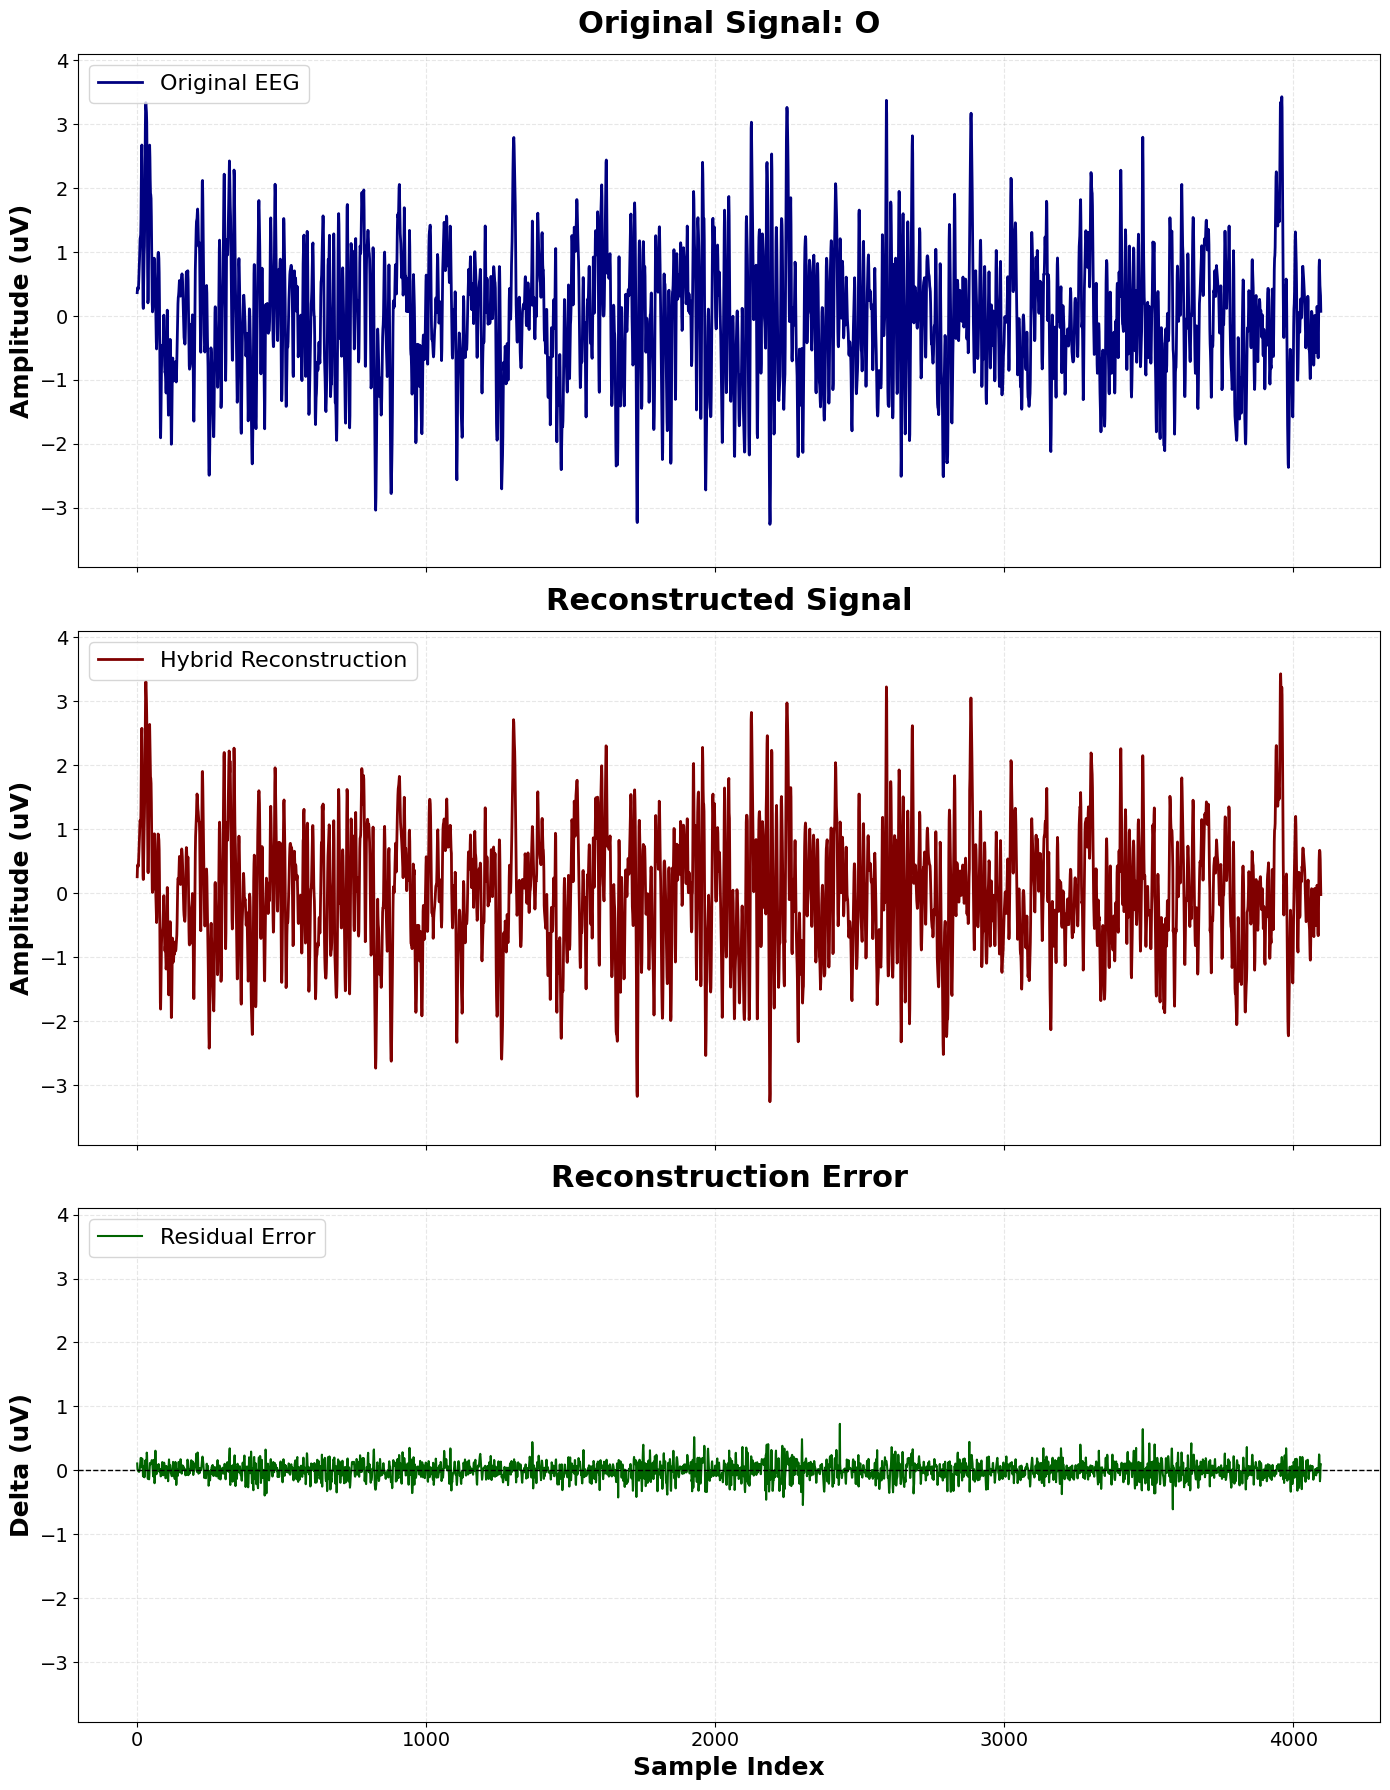


  Processing folder: S
  Loaded 100 files
    25/100 done
    50/100 done
    75/100 done
    100/100 done

  ── S Results ──
  Baseline: PRD=6.0776% SNR=24.33dB Corr=0.998636
  Hybrid:   PRD=12.1771% SNR=18.29dB Corr=0.993333
  CR=7.92x  CP=87.38%  BPS=2.0198  QS=0.6505
  Sparsity=0.6458  QuantMAE=0.001878


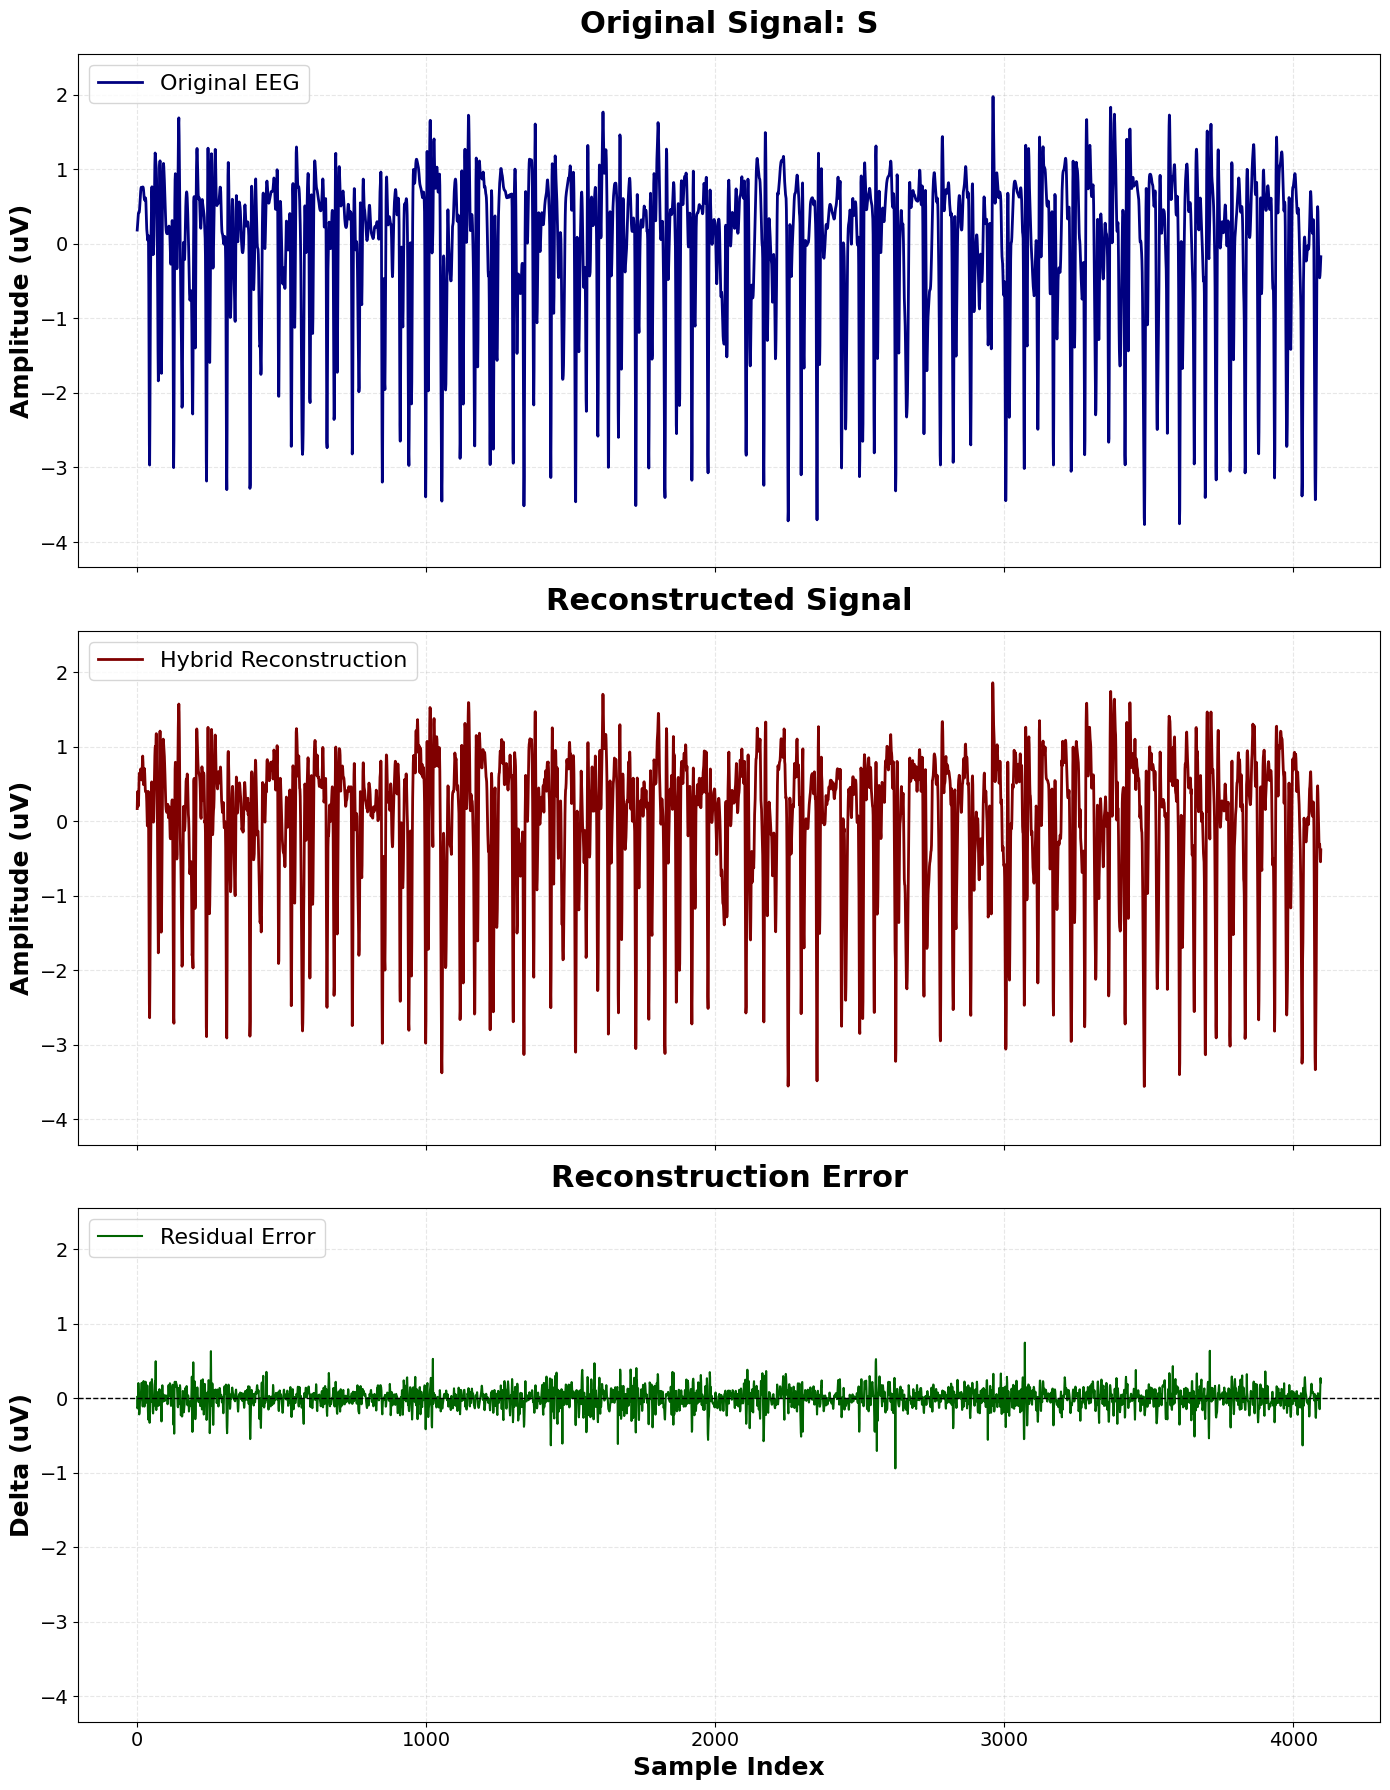


  Processing folder: Z
  Loaded 100 files
    25/100 done
    50/100 done
    75/100 done
    100/100 done

  ── Z Results ──
  Baseline: PRD=6.9917% SNR=23.11dB Corr=0.998050
  Hybrid:   PRD=14.1016% SNR=17.01dB Corr=0.990789
  CR=7.75x  CP=87.09%  BPS=2.0658  QS=0.5492
  Sparsity=0.6277  QuantMAE=0.001936


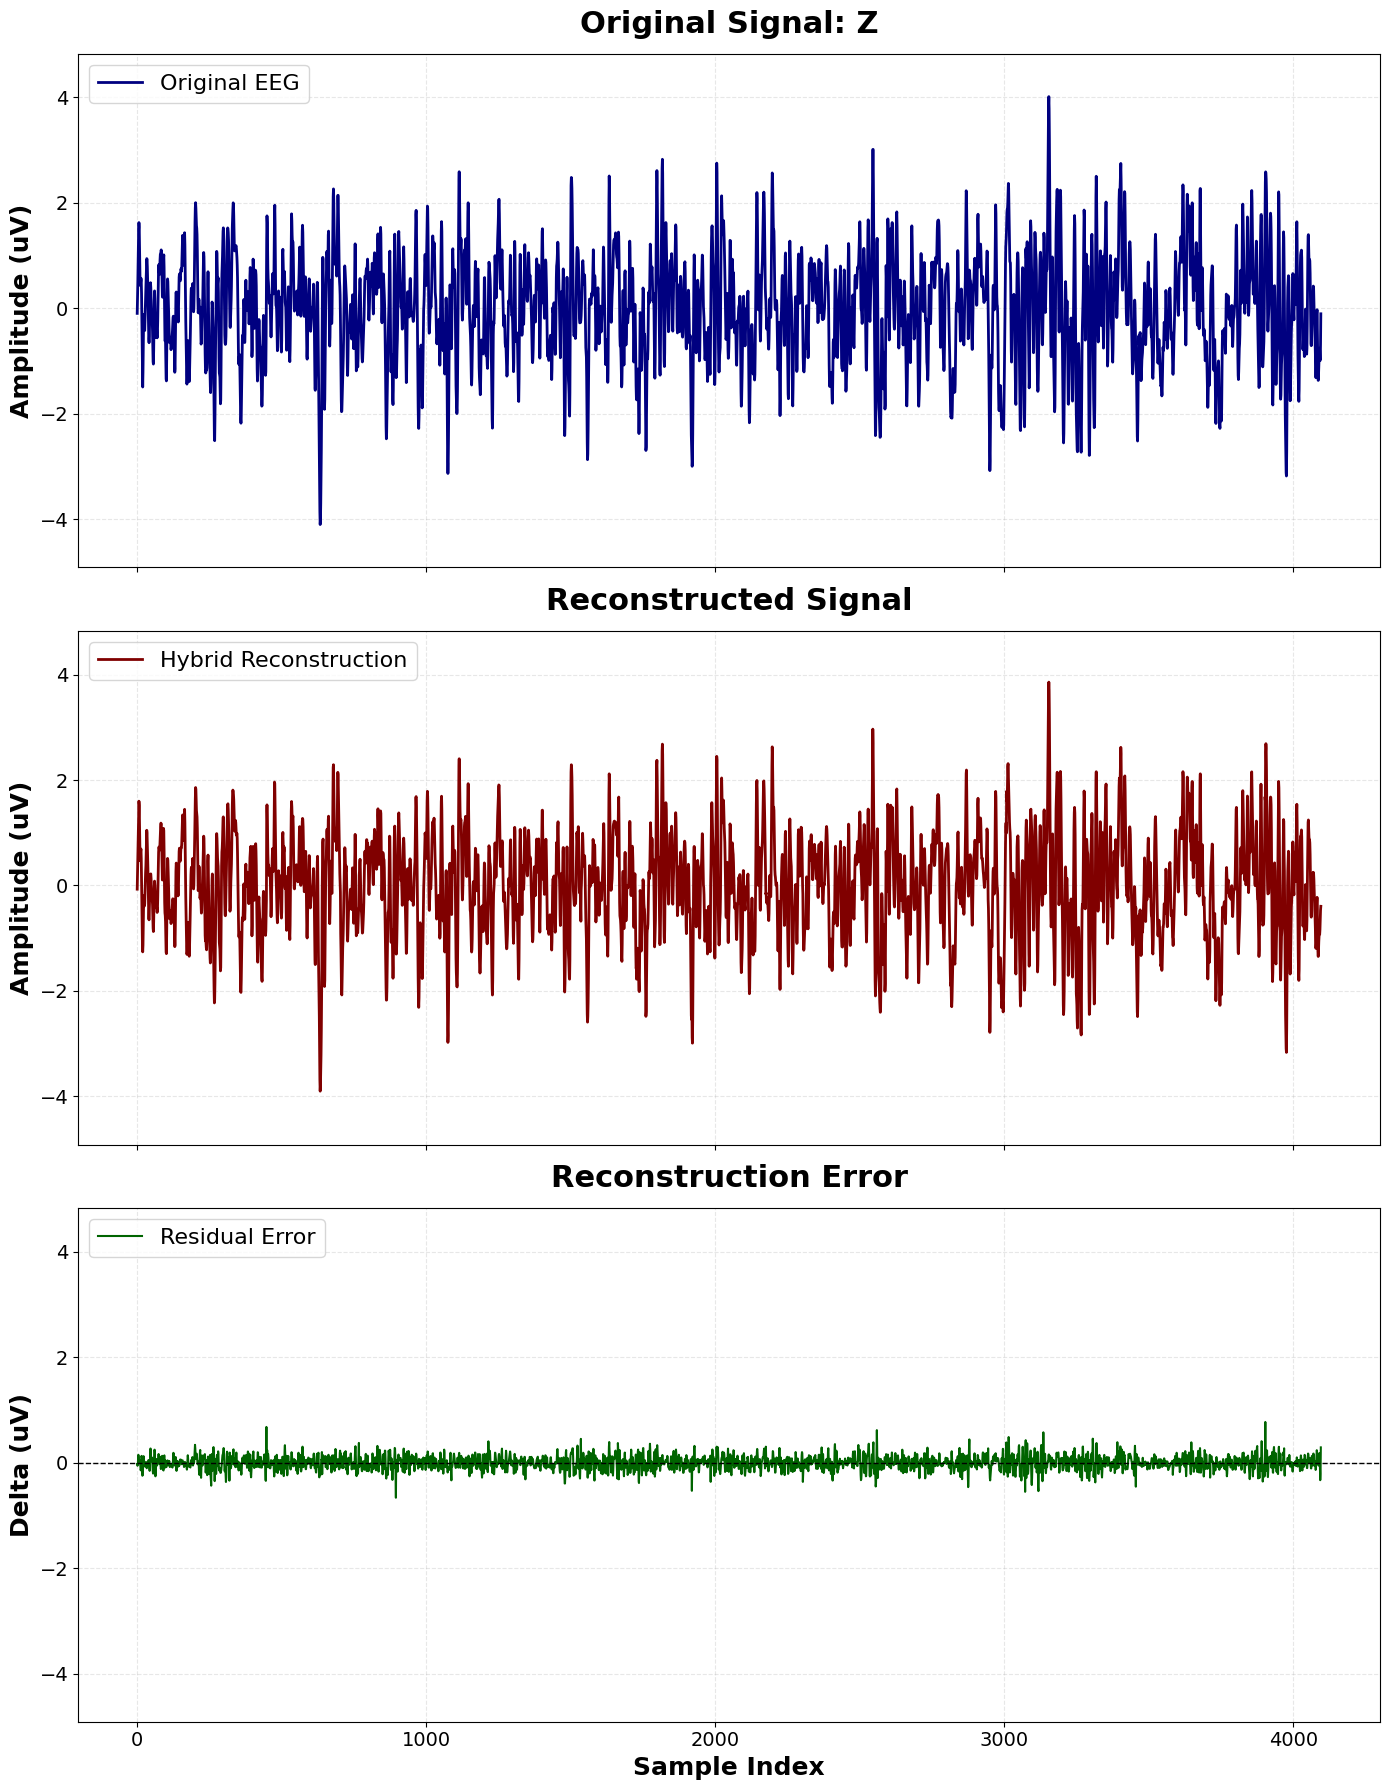


All folders processed.


In [49]:
import time

all_results = []

# ── Timing ───────────────────────────────
for _r in all_results:
    _comp   = _r.get('stats', {}).get('comp_time_tot',   0)
    _decomp = _r.get('stats', {}).get('decomp_time_tot', 0)
    _n      = max(_r.get('n_batches', 1), 1)
    print(f"  {_r.get('folder','?'):6s}  "
          f"comp={_comp/_n*1000:.2f} ms  "
          f"decomp={_decomp/_n*1000:.2f} ms")


for folder_name in FOLDERS:
    folder_path = os.path.join(BONN_DATA_DIR, folder_name)
    if not os.path.isdir(folder_path):
        print(f'\n[WARN] Folder not found: {folder_path}. Skipping.')
        continue

    print(f"\n{'='*66}")
    print(f'  Processing folder: {folder_name}')
    print(f"{'='*66}")

    tensors, file_names = load_bonn_folder(folder_path)
    if not tensors:
        print(f'  [WARN] No valid data. Skipping.')
        continue
    print(f'  Loaded {len(tensors)} files')

    edge_to_fog = EdgeToFogPipeline(scale_factor=QUANT_SCALE)

    all_originals, all_recon, all_recon_hyb, all_latents = [], [], [], []
    total_stats = {
        'original_size': 0, 'packing_size': 0, 'zstd_size': 0,
        'compression_power': 0.0, 'quantization_mae': 0.0, 'zero_fraction': 0.0
    }
    n_eval = 0

    with torch.no_grad():
        for i, data in enumerate(tensors):
            data = data.to(DEVICE)
            latent = edge(data)
            recon = fog(latent)
            decomp_latent, stats = edge_to_fog.process(latent, device=DEVICE)
            recon_hyb = fog(decomp_latent)

            all_originals.append(data.cpu())
            all_recon.append(recon.cpu())
            all_recon_hyb.append(recon_hyb.cpu())
            all_latents.append(latent.cpu())

            for key in total_stats:
                total_stats[key] += stats.get(key, 0)
            n_eval += 1

            if (i + 1) % 25 == 0:
                print(f'    {i+1}/{len(tensors)} done')

    originals = torch.cat(all_originals, dim=0)
    recon_base = torch.cat(all_recon, dim=0)
    recon_hyb  = torch.cat(all_recon_hyb, dim=0)
    latents    = torch.cat(all_latents, dim=0)

    # ── Baseline metrics ──
    prd_b  = compute_prd(originals, recon_base)
    rmse_b = compute_rmse(originals, recon_base)
    snr_b  = compute_snr(originals, recon_base)
    psnr_b = compute_psnr(originals, recon_base)
    corr_b = compute_correlation(originals, recon_base)
    cr_b   = (originals.numel() * 2) / (latents.numel() * 4)
    qs_b   = compute_qs(cr_b, prd_b)

    # ── Hybrid pipeline metrics ──
    prd_h  = compute_prd(originals, recon_hyb)
    rmse_h = compute_rmse(originals, recon_hyb)
    snr_h  = compute_snr(originals, recon_hyb)
    psnr_h = compute_psnr(originals, recon_hyb)
    prdn_h = compute_prdn(originals, recon_hyb)
    corr_h = compute_correlation(originals, recon_hyb)
    msc_h  = compute_msc(originals, recon_hyb)
    cr     = compute_compression_ratio(originals, total_stats['zstd_size'])
    cp     = (1 - total_stats['zstd_size'] / max(total_stats['original_size'], 1)) * 100
    qs_h   = compute_qs(cr, prd_h)
    bps    = compute_bps(total_stats['zstd_size'],
                         originals.shape[0] * originals.shape[2],
                         originals.shape[1])
    sparsity = total_stats['zero_fraction'] / max(n_eval, 1)
    q_mae    = total_stats['quantization_mae'] / max(n_eval, 1)

    result = {
        'folder': folder_name, 'num_files': len(tensors),
        'prd_b': prd_b, 'snr_b': snr_b, 'psnr_b': psnr_b, 'corr_b': corr_b,
        'cr_b': cr_b, 'qs_b': qs_b,
        'prd_h': prd_h, 'rmse_h': rmse_h, 'snr_h': snr_h, 'psnr_h': psnr_h,
        'prdn_h': prdn_h, 'corr_h': corr_h, 'msc_h': msc_h,
        'cr': cr, 'cp': cp, 'qs_h': qs_h, 'bps': bps,
        'sparsity': sparsity, 'q_mae': q_mae,
    }
    all_results.append(result)

    print(f'\n  ── {folder_name} Results ──')
    print(f'  Baseline: PRD={prd_b:.4f}% SNR={snr_b:.2f}dB Corr={corr_b:.6f}')
    print(f'  Hybrid:   PRD={prd_h:.4f}% SNR={snr_h:.2f}dB Corr={corr_h:.6f}')
    print(f'  CR={cr:.2f}x  CP={cp:.2f}%  BPS={bps:.4f}  QS={qs_h:.4f}')
    print(f'  Sparsity={sparsity:.4f}  QuantMAE={q_mae:.6f}')

    # Visualize the first file of this folder
    plot_bonn_reconstruction(originals[0], recon_hyb[0], folder_name, sample_idx=0)

print('\nAll folders processed.')


In [50]:

# ── Timing ───────────────────────────────
for _r in all_results:
    _comp   = _r.get('stats', {}).get('comp_time_tot',   0)
    _decomp = _r.get('stats', {}).get('decomp_time_tot', 0)
    _n      = max(_r.get('n_batches', 1), 1)
    print(f"  {_r.get('folder','?'):6s}  "
          f"comp={_comp/_n*1000:.2f} ms  "
          f"decomp={_decomp/_n*1000:.2f} ms")


W = 100
print()
print('=' * W)
print('  AVDCT-Net Edge-Fog Compression — Bonn EEG Dataset Summary'.center(W))
print('=' * W)

hdr = f"{'Class':<7} {'Files':<6} {'CR':>7} {'CP%':>7} {'PRD%':>9} {'SNR dB':>9} "
hdr += f"{'PSNR dB':>9} {'PRDN%':>9} {'Corr':>9} {'MSC':>9} {'QS':>9} {'BPS':>7}"
print(hdr)
print('-' * W)

for r in all_results:
    row  = f"{r['folder']:<7} {r['num_files']:<6} {r['cr']:>7.2f} {r['cp']:>7.2f} "
    row += f"{r['prd_h']:>9.4f} {r['snr_h']:>9.2f} {r['psnr_h']:>9.2f} "
    row += f"{r['prdn_h']:>9.4f} {r['corr_h']:>9.6f} {r['msc_h']:>9.6f} "
    row += f"{r['qs_h']:>9.4f} {r['bps']:>7.4f}"
    print(row)

print('=' * W)


  F       comp=0.00 ms  decomp=0.00 ms
  N       comp=0.00 ms  decomp=0.00 ms
  O       comp=0.00 ms  decomp=0.00 ms
  S       comp=0.00 ms  decomp=0.00 ms
  Z       comp=0.00 ms  decomp=0.00 ms

                      AVDCT-Net Edge-Fog Compression — Bonn EEG Dataset Summary                     
Class   Files       CR     CP%      PRD%    SNR dB   PSNR dB     PRDN%      Corr       MSC        QS     BPS
----------------------------------------------------------------------------------------------------
F       100       8.53   88.28    9.5745     20.38     40.54    9.5745  0.995878  0.355957    0.8911  1.8753
N       100       8.46   88.19    9.4361     20.50     35.52    9.4361  0.995977  0.366307    0.8970  1.8903
O       100       7.68   86.99   14.4722     16.79     31.55   14.4722  0.990505  0.361953    0.5309  2.0823
S       100       7.92   87.38   12.1771     18.29     33.31   12.1771  0.993333  0.358110    0.6505  2.0198
Z       100       7.75   87.09   14.1016     17.01     31

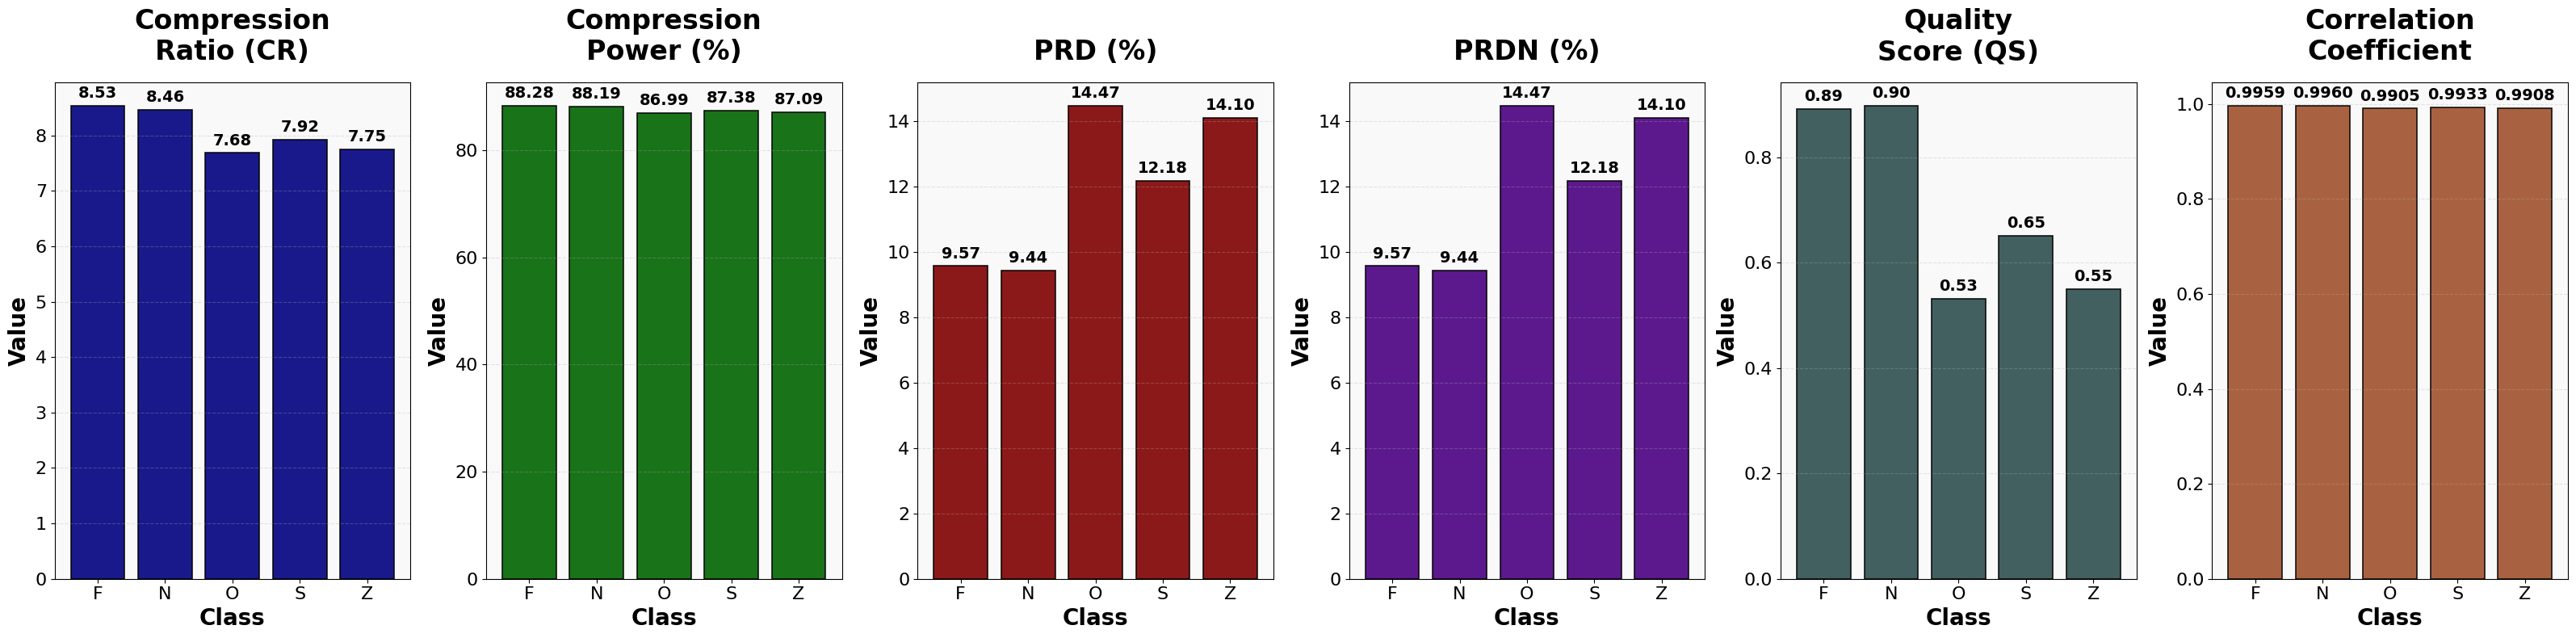

Refined single-row metrics report saved to bonn_metrics_single_row.png


In [51]:
import matplotlib.pyplot as plt

if all_results:
    # --- CONFIGURATION: DARK COLORS & LARGE FONTS ---
    # Using professional dark colors for each metric
    # Changed the final color to Deep Sienna for the Correlation Coefficient
    METRIC_COLORS = ['#000080', '#006400', '#800000', '#4B0082', '#2F4F4F', '#A0522D']

    FS_HEADING = 24  # Individual subplot titles
    FS_LABEL   = 20  # X and Y axis labels
    FS_TICKS   = 16  # X and Y axis tick labels
    FS_TEXT    = 14  # Bar value labels

    # Create figure: 1 row, 6 columns
    fig, axes = plt.subplots(1, 6, figsize=(32, 8), sharey=False)

    # Define metrics to plot
    classes = [r['folder'] for r in all_results]
    metrics = [
        ('cr',      'Compression\nRatio (CR)',     METRIC_COLORS[0]),
        ('cp',      'Compression\nPower (%)',      METRIC_COLORS[1]),
        ('prd_h',   'PRD (%)',                     METRIC_COLORS[2]),
        ('prdn_h',  'PRDN (%)',                    METRIC_COLORS[3]),
        ('qs_h',    'Quality\nScore (QS)',         METRIC_COLORS[4]),
        ('corr_h',  'Correlation\nCoefficient',    METRIC_COLORS[5]),
    ]

    for i, (ax, (key, title, color)) in enumerate(zip(axes, metrics)):
        vals = [r[key] for r in all_results]
        bars = ax.bar(classes, vals, color=color, edgecolor='black', linewidth=1.2, alpha=0.9)

        # 1. Styling Headings and Labels
        ax.set_title(title, fontsize=FS_HEADING, fontweight='bold', pad=20)
        ax.set_xlabel("Class", fontsize=FS_LABEL, fontweight='bold')
        ax.set_ylabel("Value", fontsize=FS_LABEL, fontweight='bold')

        # 2. Styling Ticks
        ax.tick_params(axis='both', which='major', labelsize=FS_TICKS)


        # 3. Cleanup Spines and add Grid
        ax.grid(axis='y', linestyle='--', alpha=0.3)
        ax.set_facecolor('#f9f9f9')

        # 4. Add Text labels on top of bars
        for bar, v in zip(bars, vals):
            height = bar.get_height()
            label_text = f'{v:.2f}' if key != 'corr_h' else f'{v:.4f}'
            ax.text(bar.get_x() + bar.get_width()/2, height + (max(vals)*0.01),
                    label_text, ha='center', va='bottom',
                    fontsize=FS_TEXT, fontweight='bold', color='black')

    # Remove overall figure title as requested
    plt.tight_layout()

    # Save the report
    plt.savefig('bonn_metrics_single_row.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f'Refined single-row metrics report saved to bonn_metrics_single_row.png')